# Impatto dell'intervallo di sanificazione

Valutazione della sensibilità della politica dinamica `c_wall` all'intervallo di sanificazione periodica dei nodi. La configurazione del cluster, il carico di lavoro e il grado di conflitto sono fissi in tutti gli scenari: l'unica variabile indipendente è `SANITIZE_INTERVAL_SECONDS`.

Ci si attende una curva a U per la latenza di scheduling: a intervalli brevi i nodi escono spesso da $\mathcal{N}$ e restano indisponibili in attesa del completamento dei task; a intervalli lunghi le tracce contestuali non vengono ripulite abbastanza in fretta e i task in conflitto restano bloccati.

## Configurazione

In [512]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "analysis")
import analysis.utils as utils

RESULTS_ROOT = Path("results")
SCENARIOS_ROOT = Path("scenarios")
FIG_DIR = Path("analysis/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR = Path("analysis/tables")
TAB_DIR.mkdir(parents=True, exist_ok=True)

INTERVALS = [1, 2, 3, 5, 10, 20, 30, 45]
SCENARIOS = [f"sanitize-{i}" for i in INTERVALS]
POINT_KEY = "sanitize_interval_seconds"

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "savefig.bbox": "tight",
    }
)

## Caricamento dei dati

In [513]:
tasks, nodes, runs = utils.load_scenarios(RESULTS_ROOT, SCENARIOS, POINT_KEY)
scenario_to_dir = {s: SCENARIOS_ROOT / s for s in SCENARIOS}

print(
    f"task totali: {len(tasks)}  |  run: {runs['replica'].count()}  "
    f"|  intervalli: {sorted(tasks['point'].unique())}"
)
runs.groupby("point")["replica"].nunique().rename("repliche")

task totali: 4000  |  run: 40  |  intervalli: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(10), np.int64(20), np.int64(30), np.int64(45)]


point
1     5
2     5
3     5
5     5
10    5
20    5
30    5
45    5
Name: repliche, dtype: int64

## 0. Controlli di sanità

Verifica preliminare: repliche per intervallo, che tutti i task siano stati sottomessi e ammessi, che nessuna run sia andata in timeout, e che non esistano rifiuti per cause diverse da `c_wall`/taint. La verifica di non violazione di `c_wall` controlla che nessun task sia stato assegnato a un nodo la cui memoria contestuale, all'istante del binding, conteneva un contesto in conflitto con quello del task.

In [514]:
checks = []
for point, g in tasks.groupby("point"):
    checks.append(
        {
            "intervallo": point,
            "repliche": g["replica"].nunique(),
            "task": len(g),
            "ammessi_ok": bool(g["admitted"].sum() == len(g)),
            "rifiuti_other": int(g["n_attempts_other"].sum()),
            "timeout": int(g["timed_out"].sum()),
            "execution_mediana": round(g["execution_s"].median(), 2),
        }
    )
display(pd.DataFrame(checks).set_index("intervallo"))

viol = utils.verify_no_wall_violation(tasks, nodes, scenario_to_dir)
if viol.empty:
    print("c_wall: nessuna violazione osservata in nessuna run.")
else:
    print(f"ATTENZIONE: {len(viol)} violazioni di c_wall!")
    display(viol)

,repliche,task,ammessi_ok,rifiuti_other,timeout,execution_mediana
intervallo,,,,,,
1,5,500,True,0,0,11.21
2,5,500,True,0,0,11.20
3,5,500,True,0,0,11.20
5,5,500,True,0,0,11.20
10,5,500,True,0,0,11.19
20,5,500,True,0,0,11.19
30,5,500,True,0,0,11.22
45,5,500,True,0,0,11.22


ATTENZIONE: 200 violazioni di c_wall!


,scenario,replica,task_id,context,node,conflicting_context,t_pod_scheduled
0,sanitize-30,0,8,x02,kind-worker4,x08,64.3497
1,sanitize-30,0,9,x10,kind-worker5,x05,34.6722
2,sanitize-30,0,24,x08,kind-worker2,x04,24.1343
3,sanitize-30,0,26,x05,kind-worker5,x10,34.7641
4,sanitize-30,0,35,x02,kind-worker4,x08,64.6395
...,...,...,...,...,...,...,...
195,sanitize-30,4,84,x01,kind-worker2,x02,102.0200
196,sanitize-30,4,88,x02,kind-worker2,x01,102.1803
197,sanitize-30,4,89,x02,kind-worker2,x01,102.1834
198,sanitize-30,4,91,x08,kind-worker2,x02,102.1998


## 1. Parametri dell'esperimento

In [515]:
r0 = runs.iloc[0]
params = pd.DataFrame(
    {
        "Parametro": [
            "Contesti $K$",
            "Densità di conflitto $\\rho$",
            "Task per run $N$",
            "Rate di sottomissione",
            "Durata task",
            "Nodi worker",
            "Repliche",
            "Intervalli valutati",
        ],
        "Valore": [
            int(tasks["context"].str.extract(r"(\d+)").astype(int).max().iloc[0]),
            r0["conflict_density"],
            int(r0["tasks"]),
            f"1 ogni {r0['rate_seconds']:g}s",
            f"{r0['task_duration_seconds']:g}s",
            nodes["node"].nunique(),
            int(runs.groupby("point")["replica"].nunique().max()),
            ", ".join(f"{i}s" for i in INTERVALS),
        ],
    }
).set_index("Parametro")
display(params)
params.to_latex(TAB_DIR / "sanitize_parametri.tex", escape=False)

,Valore
Parametro,
Contesti $K$,10
Densità di conflitto $\rho$,0.5
Task per run $N$,100
Rate di sottomissione,1 ogni 1s
Durata task,10s
Nodi worker,5
Repliche,5
Intervalli valutati,"1s, 2s, 3s, 5s, 10s, 20s, 30s, 45s"


## 2. Curva principale: latenza di scheduling

Latenza media (sottomissione → binding), barre d'errore = deviazione standard tra repliche. Asse x logaritmico. Riportate anche mediana e 95° percentile, che rivelano la bimodalità della distribuzione.

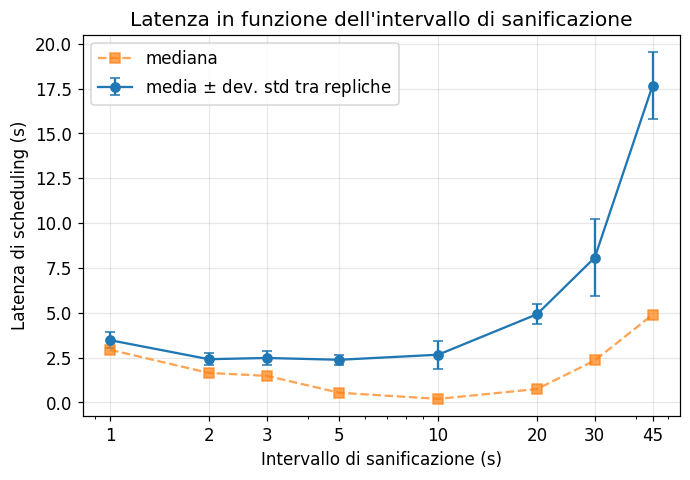

Minimo della latenza media all'intervallo = 5s (2.380s)


In [516]:
lat = utils.per_point_stat(tasks, "latency_s", "mean")
med = utils.per_point_stat(tasks, "latency_s", "median")
p95 = utils.per_point_stat(tasks, "latency_s", lambda s: np.percentile(s, 95))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    lat.index,
    lat["mean"],
    yerr=lat["std"],
    marker="o",
    capsize=3,
    label=r"media $\pm$ dev. std tra repliche",
)
ax.plot(med.index, med["mean"], marker="s", ls="--", alpha=0.7, label="mediana")
# ax.plot(p95.index, p95["mean"], marker="^", ls=":", alpha=0.7, label="95° percentile")
ax.set_xscale("log")
ax.set_xlabel("Intervallo di sanificazione (s)")
ax.set_ylabel("Latenza di scheduling (s)")
ax.set_title("Latenza in funzione dell'intervallo di sanificazione")
ax.legend()
ax.set_xticks(INTERVALS)
ax.set_xticklabels(INTERVALS)
fig.savefig(FIG_DIR / "sanitize_latenza.pdf")
plt.show()

opt = lat["mean"].idxmin()
print(f"Minimo della latenza media all'intervallo = {opt}s ({lat['mean'].min():.3f}s)")

## 3. Perché la U ha quella forma

A sinistra dominano i blocchi per taint (nodo fuori da $\mathcal{N}$); a destra i blocchi per tracce non ripulite. `mixed` indica task bloccati da entrambe le cause durante l'attesa.

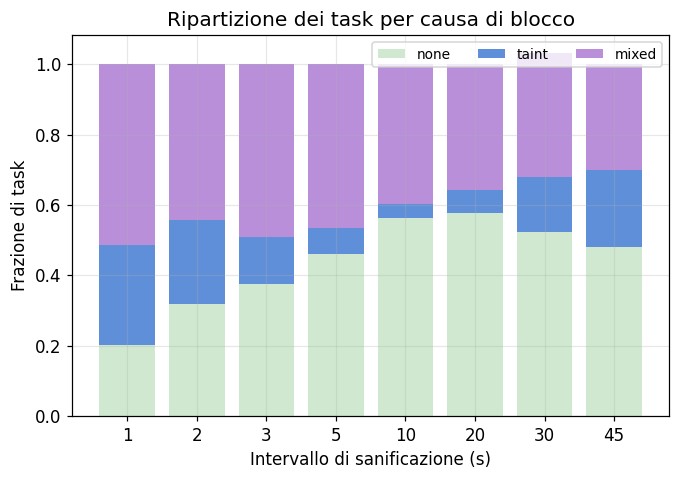

In [517]:
frac = utils.block_fraction_by_cause(tasks)
order = [c for c in ["none", "wall", "taint", "mixed", "other"] if c in frac.columns]
frac = frac[order]
colori = {
    "none": "#cfe8cf",
    "wall": "#d95f5f",
    "taint": "#5f8fd9",
    "mixed": "#b98fd9",
    "other": "#999999",
}
x = np.arange(len(frac))
bottom = np.zeros(len(frac))
fig, ax = plt.subplots(figsize=(7, 4.5))
for c in order:
    ax.bar(x, frac[c].values, bottom=bottom, label=c, color=colori.get(c))
    bottom += frac[c].values
ax.set_xticks(x)
ax.set_xticklabels(frac.index)
ax.set_xlabel("Intervallo di sanificazione (s)")
ax.set_ylabel("Frazione di task")
ax.set_title("Ripartizione dei task per causa di blocco")
ax.legend(ncol=len(order), fontsize=9)
fig.savefig(FIG_DIR / "sanitize_cause_blocco.pdf")
plt.show()

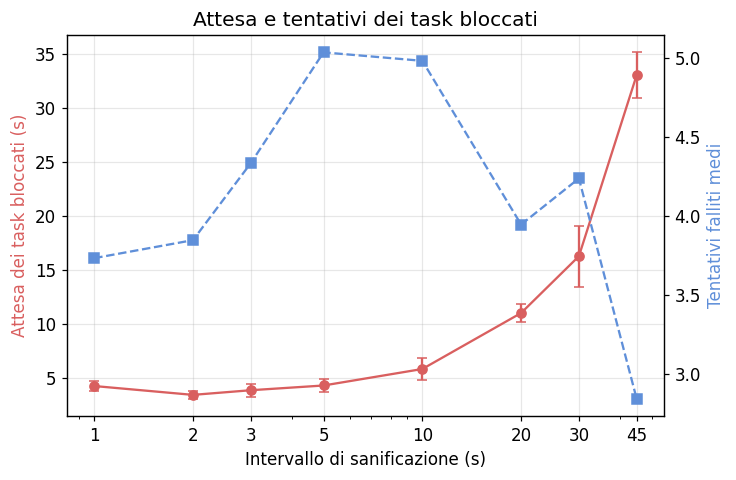

In [518]:
wait = utils.per_point_stat(tasks[tasks["blocked"]], "wait_s", "mean")
att = utils.per_point_stat(tasks[tasks["blocked"]], "n_failed_attempts", "mean")
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    wait.index,
    wait["mean"],
    yerr=wait["std"],
    marker="o",
    capsize=3,
    color="#d95f5f",
    label="attesa media",
)
ax.set_xscale("log")
ax.set_xlabel("Intervallo di sanificazione (s)")
ax.set_ylabel("Attesa dei task bloccati (s)", color="#d95f5f")
ax.set_xticks(INTERVALS)
ax.set_xticklabels(INTERVALS)
ax2 = ax.twinx()
ax2.plot(att.index, att["mean"], marker="s", ls="--", color="#5f8fd9")
ax2.set_ylabel("Tentativi falliti medi", color="#5f8fd9")
ax2.grid(False)
ax.set_title("Attesa e tentativi dei task bloccati")
fig.savefig(FIG_DIR / "sanitize_attesa.pdf")
plt.show()

## 4. Disponibilità dei nodi

Frazione di tempo in cui i nodi worker sono fuori da $\mathcal{N}$, integrata sulla durata della run.

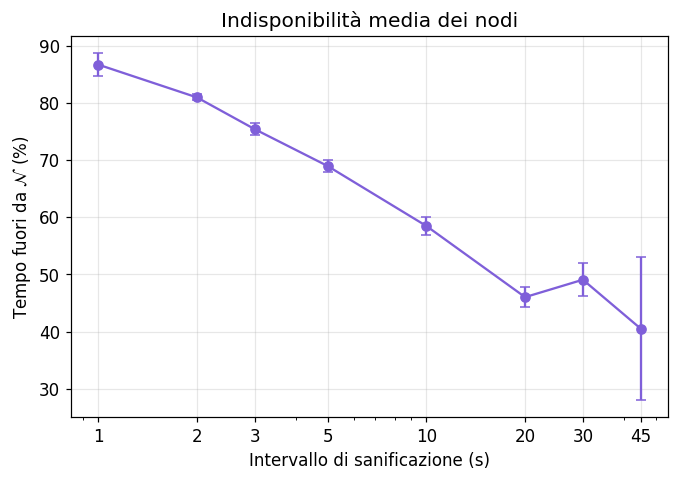

In [519]:
unavail = utils.node_unavailability(nodes, runs)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    unavail.index,
    unavail["mean"] * 100,
    yerr=unavail["std"] * 100,
    marker="o",
    capsize=3,
    color="#7f5fd9",
)
ax.set_xscale("log")
ax.set_xlabel("Intervallo di sanificazione (s)")
ax.set_ylabel(r"Tempo fuori da $\mathcal{N}$ (%)")
ax.set_title("Indisponibilità media dei nodi")
ax.set_xticks(INTERVALS)
ax.set_xticklabels(INTERVALS)
fig.savefig(FIG_DIR / "sanitize_disponibilita.pdf")
plt.show()

## 5. Distribuzione cumulata della latenza (CDF)

Tre intervalli: il più breve, quello di latenza minima, il più lungo. Il primo gradino è la frazione non bloccata; la distanza dal secondo è l'attesa tipica di sanificazione.

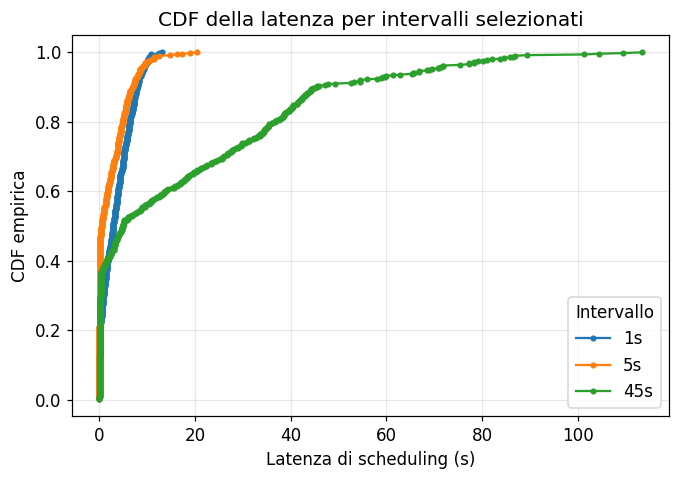

In [520]:
opt = int(lat["mean"].idxmin())
sel = sorted({INTERVALS[0], opt, INTERVALS[-1]})
fig, ax = plt.subplots(figsize=(7, 4.5))
for point in sel:
    x, y = utils.ecdf(tasks[tasks["point"] == point]["latency_s"])
    ax.plot(x, y, marker=".", ls="-", label=f"{point}s")
ax.set_xlabel("Latenza di scheduling (s)")
ax.set_ylabel("CDF empirica")
ax.set_title("CDF della latenza per intervalli selezionati")
ax.legend(title="Intervallo")
fig.savefig(FIG_DIR / "sanitize_cdf.pdf")
plt.show()

## 6. Makespan

Tempo complessivo di completamento del batch, media tra repliche.

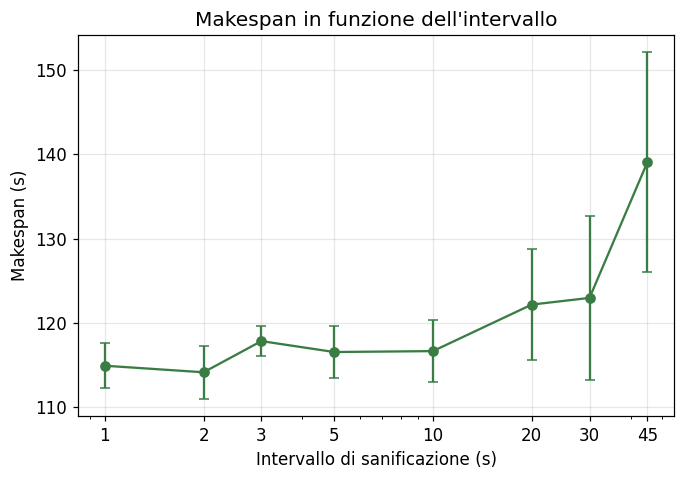

In [521]:
mk = runs.groupby("point")["makespan_s"].agg(["mean", "std"]).sort_index()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    mk.index,
    mk["mean"],
    yerr=mk["std"].fillna(0),
    marker="o",
    capsize=3,
    color="#3a7d44",
)
ax.set_xscale("log")
ax.set_xlabel("Intervallo di sanificazione (s)")
ax.set_ylabel("Makespan (s)")
ax.set_title("Makespan in funzione dell'intervallo")
ax.set_xticks(INTERVALS)
ax.set_xticklabels(INTERVALS)
fig.savefig(FIG_DIR / "sanitize_makespan.pdf")
plt.show()

## 7. Tabella riassuntiva

In [522]:
summary = pd.DataFrame(index=lat.index)
summary["Latenza media (s)"] = lat["mean"].round(3)
summary["Dev. std (s)"] = lat["std"].round(3)
summary["Mediana (s)"] = med["mean"].round(3)
summary["p95 (s)"] = p95["mean"].round(3)
summary["Bloccati (%)"] = (tasks.groupby("point")["blocked"].mean() * 100).round(1)
summary["Attesa media (s)"] = wait["mean"].round(2)
summary["Fuori da N (%)"] = (unavail["mean"] * 100).round(1)
summary["Makespan (s)"] = mk["mean"].round(2)
summary.index.name = "Intervallo (s)"
display(summary)
summary.to_latex(TAB_DIR / "sanitize_riepilogo.tex", escape=False)
print("Figure in", FIG_DIR, "| tabelle in", TAB_DIR)

,Latenza media (s),Dev. std (s),Mediana (s),p95 (s),Bloccati (%),Attesa media (s),Fuori da N (%),Makespan (s)
Intervallo (s),,,,,,,,
1,3.473,0.464,2.940,8.933,79.8,4.27,86.7,114.93
2,2.412,0.321,1.646,7.130,68.2,3.45,81.0,114.15
3,2.481,0.371,1.486,7.754,62.4,3.88,75.4,117.85
5,2.380,0.287,0.541,8.466,53.8,4.32,69.0,116.55
10,2.663,0.779,0.201,10.506,43.6,5.84,58.5,116.66
20,4.919,0.559,0.749,18.090,42.4,11.02,46.0,122.18
30,8.078,2.129,2.343,27.763,47.6,16.28,49.1,122.97
45,17.662,1.856,4.890,68.489,52.0,33.04,40.5,139.05


Figure in analysis\figures | tabelle in analysis\tables
